<a href="https://colab.research.google.com/github/LanqingDu/AdvancedBusinessAnalytics/blob/main/NB_6_TextProcessing_0.ipynb" target="_blank">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# **Text Preprocessing**



> **Instructor:** Dr. Lanqing Du  
> **Acknowledgement:** Based on [Python manuals](https://docs.python.org/3/), [Automate the Boring Stuff with Python, 2nd Edition: Practical Programming for Total Beginners](https://automatetheboringstuff.com/2e/), [Laurence Moroney](https://github.com/lmoroney) and other data Science online sources.    
> **Objective:** Introduction to text preprocessing.  
> **Instructions:** You can preview the **Table of Contents** from the side bar.

> **Disclaimer**: This notebook is prepared for instructional purposes. Some code blocks may intentionally contain errors to support the learning objectives.

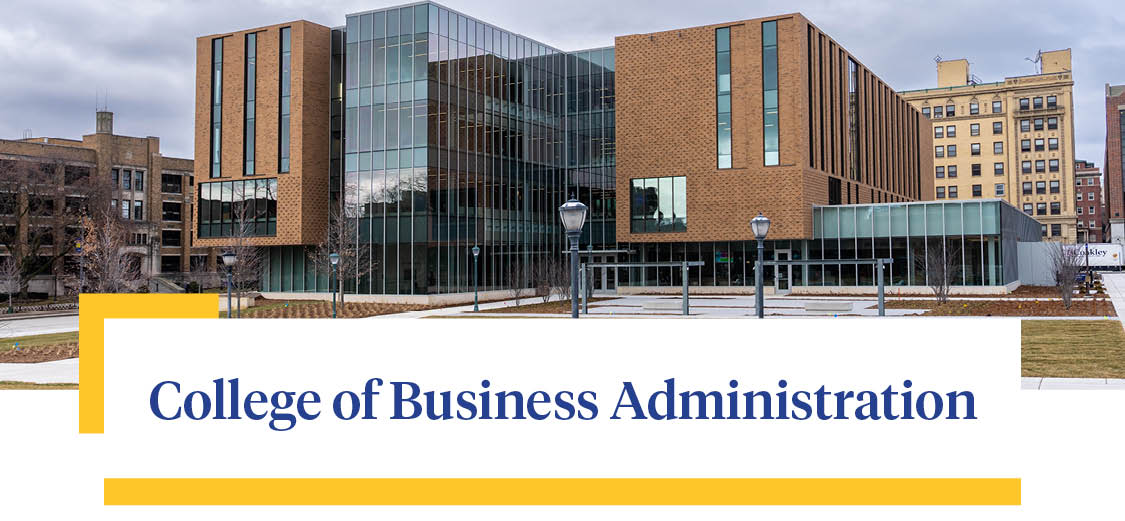
---

---

## [0. Agenda for Text Preprocessing](#Intro)


<ul>
<strong>1. Manually Entered Data</strong>
    <ul>
      <li>Initial Tokenization</li>
      <li>Exploring Test Data with Unseen Words</li>
      <li>Adding OOV (Out-of-Vocabulary) to Improve Test Handling</li>
      <li>Exploring Padding</li>
    </ul>
  
<strong>3. IMDB Data</strong></strong>
<ul>

  <li>Tokenize text and convert words into integer indices.</li>
  <li><code>beautifulsoup4</code> for HTML parsing and text cleaning.</li>
</ul>


<strong>2. JSON Data</strong>
    <ul>
      <li>Stop-word Removal</li>
      <li>Data Preparation</li>
      <li>Text Vectorization</li>
      <li>Model Development</li>
      <li>Identifying Overfitting Issues</li>
      <li>Revised Model</li>
      <li>Using the Model for Predictions</li>
      <li>Word Embeddings Exploration</li>
    </ul>

</ul>



In [ ]:
# step 0: libraries

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
import tensorflow_datasets as tfds
import numpy as np

---

## [1. Mannually Entered Data](#data)

In [ ]:
# step 1: initialize dictionary

sentences = [
    'Today is a sunny day',
    'Today is a rainy day',
    'Is it sunny today?'
]

### 1.0 Initial Tokenization

In [ ]:
# step 2: Create a Tokenizer

# ======================TODO BELOW========================
# fill in the <...>


# Create a Tokenizer object that will keep only the top 100 most common words
tokenizer = Tokenizer(num_words = <...>)

# Build the word index based on the list of sentences
tokenizer.fit_on_texts(<...>)


# ======================TODO ABOVE========================

In [ ]:
# step 3: Retrieve the dictionary


# Mapping words to their integer indices
word_index = tokenizer.word_index
print(word_index)

{'today': 1, 'is': 2, 'a': 3, 'sunny': 4, 'day': 5, 'rainy': 6, 'it': 7}


In [ ]:
# step 4: Retrieve the word index

# ======================TODO BELOW========================
# fill in the <...>

# Convert each sentence into a sequence of integers
sequences = tokenizer.texts_to_sequences(<...>)
print(sequences)

# ======================TODO ABOVE========================

[[1, 2, 3, 4, 5], [1, 2, 3, 6, 5], [2, 7, 4, 1]]


### 1.1 Exploring Test Data with unseen words

In [ ]:
# step 5: initialize test data

test_data = [
  'Today is a snowy day',
  'Will it be rainy tomorrow?'
]

In [ ]:
# step 6: tokenize test data


# ======================TODO BELOW========================
# fill in the <...>

# Convert test_data into a sequence of integers
test_sequences = tokenizer.texts_to_sequences(<...>)

# ======================TODO ABOVE========================


print(word_index)
print(test_sequences)

{'today': 1, 'is': 2, 'a': 3, 'sunny': 4, 'day': 5, 'rainy': 6, 'it': 7}
[[1, 2, 3, 5], [7, 6]]


### 1.2  Adding OOV to improve test data sequences

In [ ]:
# step 7: OOV (Out Of Vocabulary)


# ======================TODO BELOW========================
# fill in the <...>

# Create a new Tokenizer:
#     1. keeps the top 100 words and replaces unknown words with "<OOV>"
#     2. build the word index based on the training sentences

tokenizer = Tokenizer(num_words = <...>, oov_token= <...>)


# fit on the sentences
tokenizer.fit_on_texts(<...>)

# ======================TODO ABOVE========================






In [ ]:
# step 8: Retrieve the word-index mapping

# ======================TODO BELOW========================
# fill in the <...>

# retrieve the integer indices, which attribute to use
word_index = tokenizer.<...>

# ======================TODO ABOVE========================


print(word_index)

# word_index['today']


{'<OOV>': 1, 'today': 2, 'is': 3, 'a': 4, 'sunny': 5, 'day': 6, 'rainy': 7, 'it': 8}


In [ ]:
# step 9: Retrieve the sequences



# ======================TODO BELOW========================
# fill in the <...>

# convert the sequences of integers for sentences
sequences = tokenizer.texts_to_sequences(<...>)

# Convert the test data into sequences, using "<OOV>" for the test_data
test_sequences = tokenizer.texts_to_sequences(<...>)

# ======================TODO ABOVE========================



print(test_sequences)

[[2, 3, 4, 1, 6], [1, 8, 1, 7, 1]]


### 1.3 Exploring Padding

In [ ]:
# step 10: load libraries

from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# step 11: a new sequence consisting of an unequal number of words.

sentences = [
    'Today is a sunny day',
    'Today is a rainy day',
    'Is it sunny today?',
    'I really enjoyed walking in the snow today'
]

In [ ]:
# step 12: Tokenize

# note: this is the same tokenizer we defined before
tokenizer = Tokenizer(num_words = 100, oov_token="<OOV>")

# retrieve the word index
tokenizer.fit_on_texts(sentences)
word_index = tokenizer.word_index

# retrieve the sequence
sequences = tokenizer.texts_to_sequences(sentences)
print(sequences)

[[2, 3, 4, 5, 6], [2, 3, 4, 7, 6], [3, 8, 5, 2], [9, 10, 11, 12, 13, 14, 15, 2]]


In [ ]:
# step 13: add padding


# ======================TODO BELOW========================
# fill in the <...>

# Pad all sequences so they have the same length (default: pre-padding with zeros)
padded = pad_sequences(<...>)

# ======================TODO ABOVE========================


print(padded)

[[ 0  0  0  2  3  4  5  6]
 [ 0  0  0  2  3  4  7  6]
 [ 0  0  0  0  3  8  5  2]
 [ 9 10 11 12 13 14 15  2]]


In [ ]:
# step 14: post padding

# ======================TODO BELOW========================
# fill in the <...>

# Pad all sequences to the same length by adding zeros at the end of each sequence
padded = pad_sequences(<...>, padding=<...>)

# ======================TODO ABOVE========================


print(padded)

[[ 2  3  4  5  6  0  0  0]
 [ 2  3  4  7  6  0  0  0]
 [ 3  8  5  2  0  0  0  0]
 [ 9 10 11 12 13 14 15  2]]


In [ ]:
# step 15: post padding with max length



# ======================TODO BELOW========================
# fill in the <...>

# Pad with max length of 6
padded = pad_sequences(sequences, padding='post', maxlen= <...>)

# ======================TODO ABOVE========================

print(padded)

In [ ]:
# step 16: post padding with max length and truncating post positions



# ======================TODO BELOW========================
# fill in the <...>

# pad with maxlen and post truncating
padded = pad_sequences(sequences, padding='post', maxlen=6, truncating=<...>)

# ======================TODO ABOVE========================


print(padded)

[[ 2  3  4  5  6  0]
 [ 2  3  4  7  6  0]
 [ 3  8  5  2  0  0]
 [ 9 10 11 12 13 14]]


---

## [2. IMDB Data](#data)

<h3>IMDB Reviews Dataset (TensorFlow Datasets)</h3>


<h3>About the IMDB Reviews Dataset</h3>
<ul>
  <li><strong>Task Type:</strong> Binary sentiment classification</li>
  <li><strong>Number of Training Samples:</strong> 25,000 movie reviews</li>
  <li><strong>Number of Test Samples:</strong> 25,000 movie reviews</li>
  <li><strong>Labels:</strong>
    <ul>
      <li><code>0</code> → Negative review</li>
      <li><code>1</code> → Positive review</li>
    </ul>
  </li>
</ul>

<h3>Dataset Structure</h3>
<p>
Each element in <code>train_dataset</code> is a dictionary containing:
</p>

<ul>
  <li><strong>text</strong>: The full movie review (string)</li>
  <li><strong>label</strong>: Sentiment label (0 or 1)</li>
</ul>

<h3>Purpose in NLP</h3>
<p>
The IMDB dataset is widely used for training and evaluating models on
<strong>sentiment analysis</strong>, where the goal is to classify
movie reviews as positive or negative.
</p>

In [ ]:
# step 17: install the beautifulsoup

!pip install beautifulsoup4

In [ ]:
# step 18: load tensorflow datasets

train_dataset = tfds.load('imdb_reviews', split="train")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.Z4AGQ9_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.Z4AGQ9_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.Z4AGQ9_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


In [ ]:
# step 19: data preprocessing

# convert the dataset to iterable of numpy arrays

train_dataset = tfds.as_numpy(train_dataset)

In [ ]:
# step 20: data exploration v1

for item in train_dataset:
  print(item)
  break # breaks the loop after one iteration

{'label': np.int64(0), 'text': b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it."}


In [ ]:
# step 21: data exploration v2

# Alternative to check what's going on inside the dataset
train_dataset_iterator = iter(train_dataset)
next(train_dataset_iterator)

{'label': np.int64(0),
 'text': b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it."}

### 2.0  V1: Extract the text without the cleaning


In [ ]:
# step 22: text-label seperation

imdb_docs = []
imdb_labels = []

for item in train_dataset:
    imdb_docs.append(str(item['text']))
    imdb_labels.append(item['label'])

In [ ]:
# step 23: text

print(imdb_docs[0])

b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it."


use bytes objects because computers ultimately work with raw binary data, not text.

In [ ]:
# step 24: label

print(imdb_labels[0])

0



### 2.1  Tokenize

In [ ]:
# step 25: tokenize

tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=5000)

# ======================TODO BELOW========================
# fill in the <...>
# tokenize

tokenizer.fit_on_texts(<...>)
sequences = tokenizer.texts_to_sequences(<...>)

# ======================TODO ABOVE========================


print(tokenizer.word_index)

# print(imdb_docs[0])

# print(sequences[0])

{'the': 1, 'and': 2, 'a': 3, 'of': 4, 'to': 5, 'is': 6, 'br': 7, 'in': 8, 'it': 9, 'i': 10, 'this': 11, 'that': 12, 'was': 13, 'as': 14, 'for': 15, 'with': 16, 'movie': 17, 'but': 18, 'film': 19, "'s": 20, 'on': 21, 'you': 22, 'not': 23, 'are': 24, 'his': 25, 'he': 26, 'have': 27, 'be': 28, 'one': 29, 'all': 30, 'at': 31, 'by': 32, 'they': 33, 'an': 34, 'who': 35, 'so': 36, 'from': 37, 'like': 38, 'her': 39, "'t": 40, 'or': 41, 'just': 42, 'there': 43, 'about': 44, 'out': 45, "'": 46, 'has': 47, 'if': 48, 'some': 49, 'what': 50, 'good': 51, 'more': 52, 'very': 53, 'when': 54, 'she': 55, 'up': 56, 'can': 57, 'b': 58, 'time': 59, 'no': 60, 'even': 61, 'my': 62, 'would': 63, 'which': 64, 'story': 65, 'only': 66, 'really': 67, 'see': 68, 'their': 69, 'had': 70, 'were': 71, 'me': 72, 'well': 73, 'we': 74, 'than': 75, 'much': 76, 'been': 77, 'get': 78, 'bad': 79, 'will': 80, 'people': 81, 'do': 82, 'also': 83, 'other': 84, 'into': 85, 'because': 86, 'great': 87, 'first': 88, 'him': 89, 'how'

### 2.2  V2: Extract the text with clearning


In [ ]:
# step 26: include libraries

from bs4 import BeautifulSoup
import string

In [ ]:
# step 27: customize stopwords

stopwords = ["a", "about", "above", "after", "again", "against", "all", "am", "an", "and", "any", "are", "as", "at",
             "be", "because", "been", "before", "being", "below", "between", "both", "but", "by", "could", "did", "do",
             "does", "doing", "down", "during", "each", "few", "for", "from", "further", "had", "has", "have", "having",
             "he", "hed", "hes", "her", "here", "heres", "hers", "herself", "him", "himself", "his", "how",
             "hows", "i", "id", "ill", "im", "ive", "if", "in", "into", "is", "it", "its", "itself",
             "lets", "me", "more", "most", "my", "myself", "nor", "of", "on", "once", "only", "or", "other", "ought",
             "our", "ours", "ourselves", "out", "over", "own", "same", "she", "shed", "shell", "shes", "should",
             "so", "some", "such", "than", "that", "thats", "the", "their", "theirs", "them", "themselves", "then",
             "there", "theres", "these", "they", "theyd", "theyll", "theyre", "theyve", "this", "those", "through",
             "to", "too", "under", "until", "up", "very", "was", "we", "wed", "well", "were", "weve", "were",
             "what", "whats", "when", "whens", "where", "wheres", "which", "while", "who", "whos", "whom", "why",
             "whys", "with", "would", "you", "youd", "youll", "youre", "youve", "your", "yours", "yourself",
             "yourselves"]

In [ ]:
# step 28: create a translation table

# https://docs.python.org/3.9/library/stdtypes.html?highlight=maketrans#str.maketrans


# Create a translation table that removes all punctuation characters from a string
# First argument ''  → no characters are replaced
# Second argument '' → no characters are mapped to something else
# Third argument string.punctuation → all punctuation characters will be deleted

table = str.maketrans('', '', string.punctuation)

In [ ]:
# step 29: show the characters

print(table)

import pandas as pd

df = pd.DataFrame({
    "Character": [chr(k) for k in table.keys()],
    "ASCII_Code": list(table.keys()),
    "Action": list(table.values())
})

print(df.head(20))

{33: None, 34: None, 35: None, 36: None, 37: None, 38: None, 39: None, 40: None, 41: None, 42: None, 43: None, 44: None, 45: None, 46: None, 47: None, 58: None, 59: None, 60: None, 61: None, 62: None, 63: None, 64: None, 91: None, 92: None, 93: None, 94: None, 95: None, 96: None, 123: None, 124: None, 125: None, 126: None}
   Character  ASCII_Code Action
0          !          33   None
1          "          34   None
2          #          35   None
3          $          36   None
4          %          37   None
5          &          38   None
6          '          39   None
7          (          40   None
8          )          41   None
9          *          42   None
10         +          43   None
11         ,          44   None
12         -          45   None
13         .          46   None
14         /          47   None
15         :          58   None
16         ;          59   None
17         <          60   None
18         =          61   None
19         >          62   None


In [ ]:
# step 30: data cleaning and preprocess

imdb_docs = []
imdb_labels = []

for item in train_dataset:
    document = str(item['text'].decode('UTF-8').lower())
    document = document.replace(",", " , ")
    document = document.replace(".", " . ")
    document = document.replace("-", " - ")
    document = document.replace("/", " / ")
    # Create a soup
    soup = BeautifulSoup(document)
    document = soup.get_text()

    words = document.split()
    filtered_document = ""
    for word in words:
        word = word.translate(table)
        if word not in stopwords:
            filtered_document= filtered_document + word + " "
    imdb_docs.append(filtered_document)
    imdb_labels.append(item['label'])

In [ ]:
# step 31: show the processed data

print(imdb_docs[0])

print(imdb_labels[0])

absolutely terrible movie  dont lured christopher walken michael ironside  great actors  must simply worst role history  even great acting not redeem movies ridiculous storyline  movie early nineties us propaganda piece  pathetic scenes columbian rebels making cases revolutions  maria conchita alonso appeared phony  pseudo  love affair walken nothing pathetic emotional plug movie devoid real meaning  disappointed movies like  ruining actors like christopher walkens good name  barely sit  
0


In [ ]:
# step 32: tokenize

tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=25000)
tokenizer.fit_on_texts(imdb_docs)

sequences = tokenizer.texts_to_sequences(imdb_docs)
print(tokenizer.word_index)

{'movie': 1, 'film': 2, 'not': 3, 'one': 4, 'like': 5, 'just': 6, 'good': 7, 'no': 8, 'time': 9, 'even': 10, 'story': 11, 'really': 12, 'see': 13, 'can': 14, 'much': 15, 'bad': 16, 'get': 17, 'will': 18, 'also': 19, 'people': 20, 'great': 21, 'first': 22, 'dont': 23, 'made': 24, 'movies': 25, 'make': 26, 'way': 27, 'films': 28, 'characters': 29, 'think': 30, 'watch': 31, 'two': 32, 'character': 33, 'many': 34, 'seen': 35, 'life': 36, 'plot': 37, 'never': 38, 'acting': 39, 'little': 40, 'love': 41, 'best': 42, 'show': 43, 'know': 44, 'off': 45, 'ever': 46, 'better': 47, 'end': 48, 'still': 49, 'man': 50, 'say': 51, 'scene': 52, 'scenes': 53, 'go': 54, 'something': 55, 'back': 56, 'real': 57, 'watching': 58, 'years': 59, 'now': 60, 'doesnt': 61, 'though': 62, 'actors': 63, 'old': 64, 'thing': 65, 'didnt': 66, 'work': 67, 'new': 68, 'another': 69, 'nothing': 70, 'funny': 71, 'actually': 72, '10': 73, 'makes': 74, 'director': 75, 'look': 76, 'find': 77, 'going': 78, 'part': 79, 'every': 80

### 2.3  Tokenize

In [ ]:
# step 33: data dimension

print(f'Number of documents {len(imdb_docs)}')
print(f'Number of sequences {len(sequences)}')
print(f'Number of labels {len(imdb_labels)}')

Number of documents 25000
Number of sequences 25000
Number of labels 25000


In [ ]:
# step 34: test data (new data)

sentences = [
    'Today is a sunny day',
    'Today is a rainy day',
    'Is it sunny today?'
]

In [ ]:
# step 35: tokenize test data

# ======================TODO BELOW========================
# fill in the <...>
# tokenize test data defined in step 34

sequences = tokenizer.texts_to_sequences(<...>)

# ======================TODO ABOVE========================

print(sequences)

[[516, 5229, 147], [516, 6489, 147], [5229, 516]]


In [ ]:
# step 36: reverse dictionary to translate numbers back to the original sentence

reverse_word_index = {}

for (key, value) in tokenizer.word_index.items():
    reverse_word_index[value] = key

# shorter version:
# reverse_word_index = dict([(value, key) for (key, value) in tokenizer.word_index.items()])


# reverse_word_index[516] returns 'today'
# reverse_word_index[5229] returns 'sunny'
# reverse_word_index[147] returns 'day'

In [ ]:
# step 37: decoded

decoded_review = ""

for i in sequences[0]:
    word = reverse_word_index.get(i, '?')
    decoded_review = decoded_review + ' ' + word

# shorter version:
# decoded_review = ' '.join([reverse_word_index.get(i, '?') for i in sequences[0]])

print(decoded_review)

---

## [3. JSON Data](#text)

In [ ]:
# step 38: load libraries

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import numpy as np
import matplotlib.pyplot as plt

import json
from bs4 import BeautifulSoup
import string
from collections import OrderedDict

### 3.0  Stop-words

In [ ]:
# step 39: define stopwords


stopwords = ["a", "about", "above", "after", "again", "against", "all", "am", "an", "and", "any", "are", "as", "at",
             "be", "because", "been", "before", "being", "below", "between", "both", "but", "by", "could", "did", "do",
             "does", "doing", "down", "during", "each", "few", "for", "from", "further", "had", "has", "have", "having",
             "he", "hed", "hes", "her", "here", "heres", "hers", "herself", "him", "himself", "his", "how",
             "hows", "i", "id", "ill", "im", "ive", "if", "in", "into", "is", "it", "its", "itself",
             "lets", "me", "more", "most", "my", "myself", "nor", "of", "on", "once", "only", "or", "other", "ought",
             "our", "ours", "ourselves", "out", "over", "own", "same", "she", "shed", "shell", "shes", "should",
             "so", "some", "such", "than", "that", "thats", "the", "their", "theirs", "them", "themselves", "then",
             "there", "theres", "these", "they", "theyd", "theyll", "theyre", "theyve", "this", "those", "through",
             "to", "too", "under", "until", "up", "very", "was", "we", "wed", "well", "were", "weve", "were",
             "what", "whats", "when", "whens", "where", "wheres", "which", "while", "who", "whos", "whom", "why",
             "whys", "with", "would", "you", "youd", "youll", "youre", "youve", "your", "yours", "yourself",
             "yourselves"]

# Create a translation table used for character-level string transformations
# First argument ''  → no characters are being replaced
# Second argument '' → no replacement characters are provided
# Third argument string.punctuation → specifies characters to remove
# string.punctuation contains common punctuation symbols like ! " # $ % & ' ( ) * + , - . / : ; < = > ? @ [ \ ] ^ _ ` { | } ~
# This table is typically used with the translate() method to remove punctuation from text

table = str.maketrans('', '', string.punctuation)

### 3.1  Data

<h3>Dataset Description: Sarcasm Detection (sarcasm.json)</h3>

<p>
This dataset contains news headlines labeled for sarcasm detection. Each record is stored in
<strong>JSON</strong> format and represents a single headline with an associated binary class label.
The dataset is designed for <strong>binary text classification</strong>, where the goal is to predict
whether a given headline is sarcastic or not.
</p>

<h3>Fields</h3>
<ul>
  <li><strong>headline</strong>: The text of the news headline.</li>
  <li><strong>is_sarcastic</strong>: Binary label indicating sarcasm status (1 = sarcastic, 0 = not sarcastic).</li>
  <li><strong>article_link</strong>: URL to the original article source.</li>
</ul>

<h3>Task</h3>
<p>
Given a headline (<code>headline</code>), train a model to predict <code>is_sarcastic</code>.
This makes the dataset suitable for supervised learning methods such as logistic regression,
neural networks, and deep learning models using word embeddings.
</p>

<h3>Typical Use Cases</h3>
<ul>
  <li>Sarcasm detection in short text</li>
  <li>NLP preprocessing and feature engineering practice</li>
  <li>Training and evaluating binary classification models</li>
  <li>Benchmarking embedding-based neural networks</li>
</ul>

In [ ]:
# step 40: download data

!wget https://raw.githubusercontent.com/ashwaniYDV/sarcasm-detection-tensorflow/main/sarcasm.json

--2026-03-03 20:15:53--  https://raw.githubusercontent.com/ashwaniYDV/sarcasm-detection-tensorflow/main/sarcasm.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5616834 (5.4M) [text/plain]
Saving to: ‘sarcasm.json.2’

sarcasm.json.2      100%[===================>]   5.36M  --.-KB/s    in 0.07s   

2026-03-03 20:15:54 (71.5 MB/s) - ‘sarcasm.json.2’ saved [5616834/5616834]



In [ ]:
# step 41: oad the json file

with open("sarcasm.json", 'r') as f:
    datastore = json.load(f)

In [ ]:
# step 42: preview the data loaded from json file

datastore[0]

{'article_link': 'https://www.huffingtonpost.com/entry/versace-black-code_us_5861fbefe4b0de3a08f600d5',
 'headline': "former versace store clerk sues over secret 'black code' for minority shoppers",
 'is_sarcastic': 0}

In [ ]:
# step 43: convert json file to list

# define list
documents = []
labels = []
urls = []

# load data iteratively
for item in datastore:
    document = item['headline'].lower()
    document = document.replace(",", " , ")
    document = document.replace(".", " . ")
    document = document.replace("-", " - ")
    document = document.replace("/", " / ")

    # beautifulsoup to remove HTML tags if dataset comes from web scraping
    soup = BeautifulSoup(document)
    document = soup.get_text()

    # split it into words
    words = document.split()
    filtered_document = ""
    for word in words:

        # remove the punctuation
        word = word.translate(table)
        # remove stopwords
        if word not in stopwords:
            filtered_document = filtered_document + word + " "

    documents.append(filtered_document)
    labels.append(item['is_sarcastic'])
    urls.append(item['article_link'])

In [ ]:
# step 44: print the first sentence

documents[0]

'former versace store clerk sues secret black code minority shoppers '

### 3.2 Vectorization

In [ ]:
# step 45: define the params for vectorization

# any word outside the top 10000 will be removed
vocab_size = 10000

# each word is represented by a 16-dimensional vector
# returning (10000, 16)
embedding_dim = 16

# each sentence will be convered to exactly 100 tokens
max_length = 100

# if more > 100, padded
trunc_type='post'

# if less < 100, truncated
padding_type='post'

# unkown words will be replaced
oov_tok = "<OOV>"

# train_validation
training_size = 23000

In [ ]:
# step 46: Split the datasets into training and validation sets

training_docs = documents[0:training_size]
validation_docs = documents[training_size:]

training_labels = labels[0:training_size]
validation_labels = labels[training_size:]

Note: will the step 22 be a good way for train-validation split?

In [ ]:
# step 47: Tokenize the documents

# ======================TODO BELOW========================
# fill in the <...>

# pass vocab_size to num_words; oov_tol to oov_token
tokenizer = Tokenizer(num_words=<...>, oov_token=<...>)

# fit on training_docs
tokenizer.fit_on_texts(<...>)

# ======================TODO ABOVE========================


word_index = tokenizer.word_index

In [ ]:
# step 48: Sequence and pad the tokenized documents.

# ======================TODO BELOW========================
# fill in the <...>

# tokenize: convert text_to_sequences for training_docs
training_sequences = tokenizer.<...>(training_docs)

# tokenize: convert text_to_sequences for validation_docs
validation_sequences = tokenizer.<...>(<...>)

# ======================TODO ABOVE========================


training_padded = pad_sequences(training_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

validation_padded = pad_sequences(validation_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

In [ ]:
# step 49: Prepare the data for TensorFlow.

# # We need the following step to avoid the possible error of `Failed to find data adapter that can handle input: <class 'numpy.ndarray'>`

training_padded = np.array(training_padded)
training_labels = np.array(training_labels)
validation_padded = np.array(validation_padded)
validation_labels = np.array(validation_labels)

### 3.3  Model


In [ ]:
# step 50: NN architecture for text



# ======================TODO BELOW========================
# fill in the <...>

# Create a sequential neural network model
model1 = tf.keras.Sequential([

    # Convert word indices into dense embedding vectors
    # Embedding layer: maps each token index to a dense vector of size embedding_dim
    tf.keras.layers.Embedding(<...>, <...>),

    # use GolbalAveragePolling1D to Reduce each sequence of embeddings into a single average vector
    tf.keras.layers.<...>,

    # Fully connected layer with 24 neurons using ReLU activation
    tf.keras.layers.<...>(<...>, activation=<...>),

    # Output layer with 1 neuron using sigmoid activation (for binary classification)
    tf.keras.layers.Dense(<...>, activation=<...>)
])

# ======================TODO ABOVE========================




- Note: `GlobalAveragePooling1D` is similar to `AveragePooling1D` with the main difference that `GlobalAveragePooling1D` takes the average among all steps.

- For instance, from the previous layer, we have vocab_size = 10,000 and embedding_dim = 16. The interpretation is that it takes the average of the 10,000 words for each of the 16 embedding dimensions leading to a total of 16 values out of the 160,000 parameters from the previous layer.

In [ ]:
# step 51: compile the NN model

# ======================TODO BELOW========================
# fill in the <...>

# because we use sigmoid activation for binary classification, we use binary_crossetropy for the loss
model1.compile(loss=<...>,
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
               metrics=['accuracy'])

# ======================TODO ABOVE========================

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# step 52: train the NN model

# ======================TODO BELOW========================
# fill in the <...>
# fit a model using training dataset
history = model1.fit(<...>,
                     <...>,
                     epochs = 100,
                     validation_data=(validation_padded, validation_labels))

# ======================TODO ABOVE========================




Epoch 1/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5586 - loss: 0.6869 - val_accuracy: 0.5700 - val_loss: 0.6836
Epoch 2/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5643 - loss: 0.6842 - val_accuracy: 0.5700 - val_loss: 0.6820
Epoch 3/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5596 - loss: 0.6843 - val_accuracy: 0.5700 - val_loss: 0.6808
Epoch 4/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5588 - loss: 0.6832 - val_accuracy: 0.5700 - val_loss: 0.6788
Epoch 5/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5594 - loss: 0.6808 - val_accuracy: 0.5700 - val_loss: 0.6756
Epoch 6/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5543 - loss: 0.6783 - val_accuracy: 0.5697 - val_loss: 0.6711
Epoch 7/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5581 - loss: 0.6723 - val_accuracy: 0.5913 - val_loss: 0.6665
Epoch 8/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5743 - loss: 0.6634 - val_accu

### 3.4 Identifying Overfitting Issues

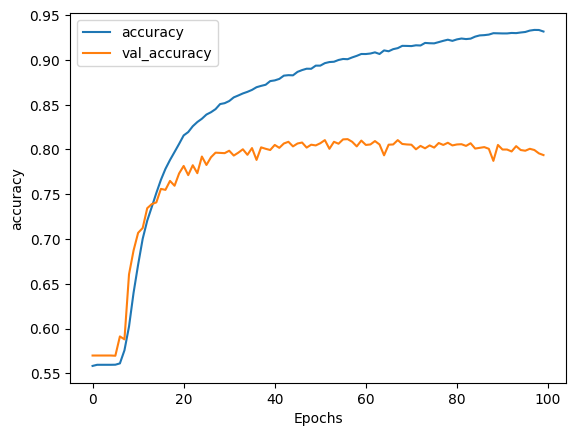

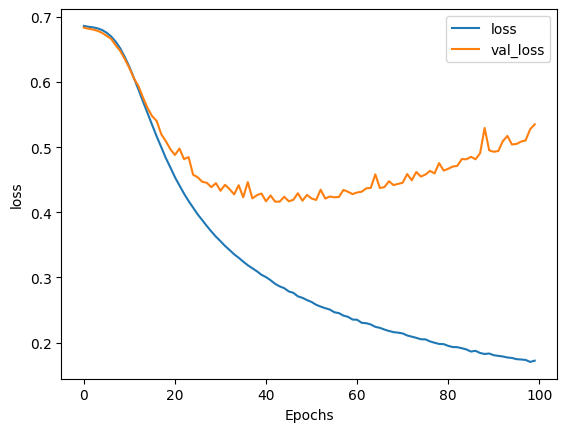

In [ ]:
# step 53: plot the performance over epoches

def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

Observing the above two plots:

- Is there a significant performance gap between the training and validation datasets?
- Are the training and validation loss curves diverging over time?

### 3.5  Revised Model

In [ ]:
# step 54: print the word count dictionary (ordered dictionary)

wc = tokenizer.word_counts
print(wc)
type(wc)

OrderedDict({'former': 90, 'versace': 1, 'store': 44, 'clerk': 9, 'sues': 13, 'secret': 78, 'black': 230, 'code': 19, 'minority': 12, 'shoppers': 2, 'roseanne': 3, 'revival': 10, 'catches': 10, 'thorny': 3, 'political': 73, 'mood': 13, 'better': 100, 'worse': 34, 'mom': 163, 'starting': 37, 'fear': 39, 'sons': 35, 'web': 16, 'series': 53, 'closest': 5, 'thing': 126, 'will': 484, 'grandchild': 2, 'boehner': 26, 'just': 501, 'wants': 120, 'wife': 73, 'listen': 21, 'not': 634, 'come': 92, 'alternative': 13, 'debt': 23, 'reduction': 4, 'ideas': 35, 'j': 41, 'k': 39, 'rowling': 5, 'wishes': 33, 'snape': 2, 'happy': 51, 'birthday': 57, 'magical': 25, 'way': 239, 'advancing': 2, 'worlds': 79, 'women': 289, 'fascinating': 3, 'case': 77, 'eating': 64, 'lab': 8, 'grown': 17, 'meat': 25, 'ceo': 56, 'send': 33, 'kids': 164, 'school': 207, 'work': 168, 'company': 78, 'top': 106, 'snake': 9, 'handler': 4, 'leaves': 60, 'sinking': 3, 'huckabee': 17, 'campaign': 162, 'fridays': 16, 'morning': 86, 'ema

collections.OrderedDict

We can sort this dictionary based on the frequency of words because it's an OrderedDict. By doing so, we can get a sense of how many words we need to include in our document vectors to decrease the amount of required computing resources and at the same time avoid overfitting.

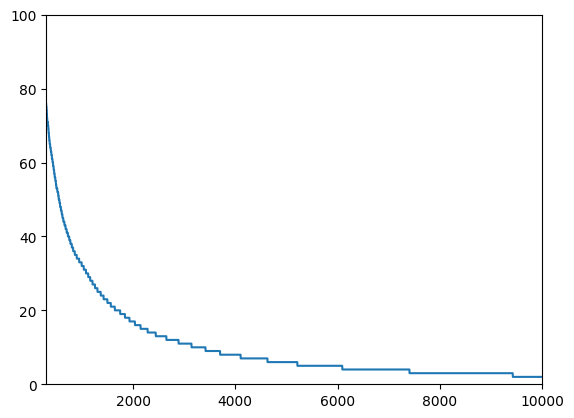

In [ ]:
# step 55: sort the dictionary based on the frequency

# Explor data to determine the optimal word count for our document vectors, reducing computational demands while minimizing overfitting

# Create an OrderedDict of word counts sorted in descending order by frequency
newlist = (OrderedDict(sorted(wc.items(), key=lambda t: t[1], reverse=True)))

xs=[]
ys=[]

counter = 1

for item in newlist:
  xs.append(counter)
  counter = counter + 1
  ys.append(newlist[item])

plt.plot(xs,ys)
plt.axis([300,10000,0,100])
plt.show()

In [ ]:
# step 56: tokenize to remove low frequency words

vocab_size = 2000

# Create a new Tokenizer:
#     1. keeps the top vocab_size words and replaces unknown words with "<OOV>"
#     2. build the word index based on the training sentences

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(training_docs)

training_sequences = tokenizer.texts_to_sequences(training_docs)
training_padded = pad_sequences(training_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

validation_sequences = tokenizer.texts_to_sequences(validation_docs)
validation_padded = pad_sequences(validation_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

training_padded = np.array(training_padded)
training_labels = np.array(training_labels)
validation_padded = np.array(validation_padded)
validation_labels = np.array(validation_labels)

In [ ]:
# step 57: nn architecture

model2 = tf.keras.Sequential([
  tf.keras.layers.Embedding(vocab_size, embedding_dim),
  tf.keras.layers.GlobalAveragePooling1D(),

  # reduce the number of neurons in the hidden layer
  tf.keras.layers.Dense(8, activation='relu'),

  # add a `Droupout` layer to reduce overfitting.
  tf.keras.layers.Dropout(0.25),

  #
  tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
# step 58: compile and fit model

model2.compile(loss='binary_crossentropy',
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
               metrics=['accuracy'])

history2 = model2.fit(training_padded, training_labels, epochs = 100, validation_data=(validation_padded, validation_labels))

Epoch 1/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5607 - loss: 0.6882 - val_accuracy: 0.5700 - val_loss: 0.6828
Epoch 2/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5501 - loss: 0.6888 - val_accuracy: 0.5700 - val_loss: 0.6829
Epoch 3/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5652 - loss: 0.6844 - val_accuracy: 0.5700 - val_loss: 0.6823
Epoch 4/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5596 - loss: 0.6844 - val_accuracy: 0.5700 - val_loss: 0.6823
Epoch 5/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5574 - loss: 0.6857 - val_accuracy: 0.5700 - val_loss: 0.6806
Epoch 6/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5572 - loss: 0.6843 - val_accuracy: 0.5700 - val_loss: 0.6805
Epoch 7/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5607 - loss: 0.6823 - val_accuracy: 0.5700 - val_loss: 0.6792
Epoch 8/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5581 - loss: 0.6820 - val_accu

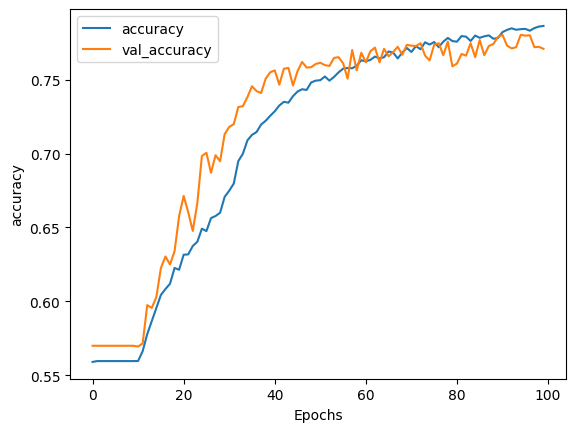

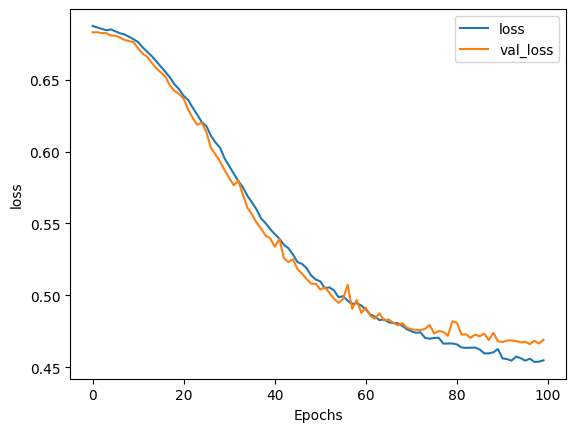

In [ ]:
# step 59: updated plot

plot_graphs(history2, "accuracy")
plot_graphs(history2, "loss")

Instead of `Dropout()` we can use regularization.

* L1 regularization is often called lasso (least absolute shrinkage and selection operator) regularization. It effectively helps us ignore the zero or close-to-zero weights when calculating a result in a layer.
https://www.tensorflow.org/api_docs/python/tf/keras/regularizers/L1

* L2 regularization is often called ridge regression because it pushes values apart by taking their squares. This tends to amplify the differences between nonzero values and zero or close-to-zero ones, creating a ridge effect.
https://www.tensorflow.org/api_docs/python/tf/keras/regularizers/L2

In [ ]:
# step 60: updated nn structure


# ======================TODO BELOW========================
# fill in the <...>

# Create a sequential neural network model
model3 = tf.keras.Sequential([

  # Convert word indices into dense embedding vectors of fixed size
  tf.keras.layers.Embedding(vocab_size, embedding_dim),

  # Reduce the sequence of embeddings into a single averaged vector
  tf.keras.layers.GlobalAveragePooling1D(),

  # Hidden dense layer with 8 neurons, ReLU activation, and L2 regularization to reduce overfitting
  tf.keras.layers.Dense(
      8,
      activation='relu',
      kernel_regularizer=tf.keras.regularizers.<...>(0.01)
  ),

  # Output layer with 1 neuron and sigmoid activation
  # we want the probability of one class: use sigmoid activation function
  tf.keras.layers.Dense(1, activation='sigmoid')
])

# ======================TODO ABOVE========================





model3.compile(loss='binary_crossentropy',
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
               metrics=['accuracy'])

history3 = model3.fit(training_padded,
                      training_labels,
                      epochs = 100,
                      validation_data=(validation_padded, validation_labels))

Epoch 1/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5565 - loss: 0.7862 - val_accuracy: 0.5700 - val_loss: 0.7542
Epoch 2/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5631 - loss: 0.7488 - val_accuracy: 0.5700 - val_loss: 0.7293
Epoch 3/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5577 - loss: 0.7270 - val_accuracy: 0.5700 - val_loss: 0.7116
Epoch 4/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5602 - loss: 0.7107 - val_accuracy: 0.5700 - val_loss: 0.7002
Epoch 5/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5592 - loss: 0.7007 - val_accuracy: 0.5700 - val_loss: 0.6931
Epoch 6/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5609 - loss: 0.6939 - val_accuracy: 0.5700 - val_loss: 0.6887
Epoch 7/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5607 - loss: 0.6900 - val_accuracy: 0.5700 - val_loss: 0.6860
Epoch 8/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5561 - loss: 0.6889 - val_accu

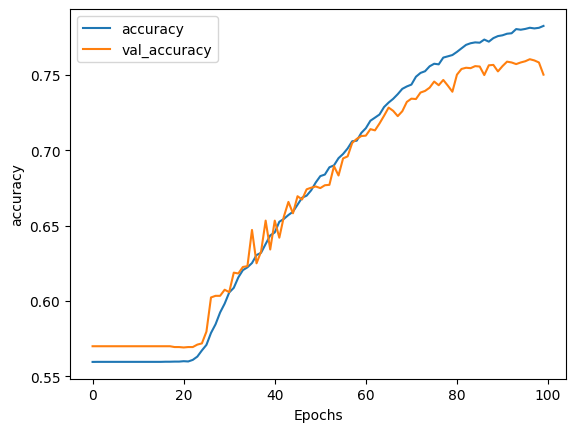

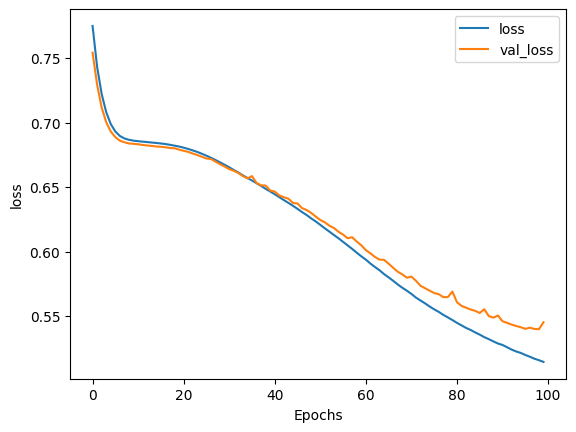

In [ ]:
# step 61: updated visualization

plot_graphs(history3, "accuracy")
plot_graphs(history3, "loss")

### 3.6 Use the Model

In [ ]:
# step 62: apply the model

# preprocess text data
sentences = ["granny starting to fear spiders in the garden might be real", "game of thrones season finale showing this sunday night"]

sequences = tokenizer.texts_to_sequences(sentences)

padded = pad_sequences(sequences,
                       maxlen=max_length,
                       padding=padding_type,
                       truncating=trunc_type)


# use model prediction



# ======================TODO BELOW========================
# fill in the <...>

# make prediction
model1.predict(<...>)

# ======================TODO ABOVE========================





### 3.7  Embeddings



In [ ]:
# step 63: create reverse word index dictionary to find the word associated with each index

reverse_word_index = {}

for (key, value) in word_index.items():
  reverse_word_index[value] = key

# Alternative code:
# reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# Show the first 5 items from reverse_word_index
print(list(reverse_word_index.items())[:5])

# show the reverse_word_index corresponding to value = 2
reverse_word_index[2]

[(1, '<OOV>'), (2, 'new'), (3, 'trump'), (4, 'man'), (5, 'not')]


'new'

In [ ]:
# step 43: get the embeddings

# access the embedding layers: index 0
weights = model1.layers[0].get_weights()[0]

print(weights.shape) # shape: (vocab_size, embedding_dim)

# return the embedding vector
# recall that embedding_dim = 16
# extracting the learned word representations from the embedding layer after training
# this is for unknow terms
weights[0]

# you can transfer the embeddings to another model
# initialize another network with those saved embeddings
# compare with pretrained embeddings (glove, word2vec)

(10000, 16)


array([ 0.46212062, -0.00332315,  0.41188332,  0.02500938,  0.00207911,
       -0.1282905 , -0.0893943 ,  0.03961777, -0.14791825,  0.06249904,
        0.06857146,  0.05586868, -0.1543369 ,  0.05510078,  0.01444756,
        0.2791785 ], dtype=float32)